# FM-Latent Decoder — FALCON Challenge

Flow Matching decoder that:
1. Compresses raw spike counts to a 32-dim PCA latent during training
2. Learns a velocity field `V_θ(x_τ, h, τ) → R^out_dim`
3. At inference, integrates the field with a simple Euler ODE to decode

 ## Environment check & installs

In [14]:
import subprocess, sys

# Install FALCON if not already present
try:
    import falcon_challenge
    print("falcon_challenge already installed")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "falcon-challenge"])

import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

falcon_challenge already installed
PyTorch : 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


## 1) Imports

In [15]:
from __future__ import annotations

import os
import copy
from typing import List, Optional

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

from pynwb import NWBHDF5IO
from falcon_challenge.config import FalconConfig, FalconTask
from falcon_challenge.dataloaders import bin_units
from falcon_challenge.interface import BCIDecoder
import matplotlib.pyplot as plt
import subprocess, sys


## 2)Hyperparameters and Data Download


In [16]:
DANDISET_ID = "000954"
SUBJECT_TO_LOCAL = {
    "sub-HumanPitt-held-in-calib":  "data/h1/held_in_calib",
    "sub-HumanPitt-held-out-calib": "data/h1/held_out_calib",
    "sub-HumanPitt-held-in-minival": "data/h1/minival",
}

def _needs_download(mapping):
    for sub, local_path in mapping.items():
        if not os.path.isdir(local_path) or not any(f.endswith(".nwb") for f in os.listdir(local_path)):
            return True
    return False

if _needs_download(SUBJECT_TO_LOCAL):
    print("Downloading FALCON H1 data from DANDI ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "dandi"])
    from dandi.download import download as dandi_download

    for sub, local_path in SUBJECT_TO_LOCAL.items():
        os.makedirs(local_path, exist_ok=True)
        print(f"  {sub} → {local_path}")
        dandi_download(
            urls=[f"https://api.dandiarchive.org/api/dandisets/{DANDISET_ID}/versions/draft/assets/?path={sub}"],
            output_dir=local_path,
        )
    print("Download complete.")
else:
    print("All data present — skipping download.")

# Confirm paths and file counts
print("\nData paths:")
for sub, local_path in SUBJECT_TO_LOCAL.items():
    abs_path = os.path.abspath(local_path)
    if os.path.isdir(local_path):
        # find nwb files
        nwb_files = []
        for root, dirs, files in os.walk(local_path):
            nwb_files += [os.path.join(root, f) for f in files if f.endswith(".nwb")]
        print(f"  {abs_path}: {len(nwb_files)} NWB files")
        # If nested, print actual location
        if nwb_files:
            actual_dir = os.path.dirname(nwb_files[0])
            if os.path.abspath(actual_dir) != abs_path:
                print(f"    ↳ actual NWB location: {actual_dir}")
    else:
        print(f"  {abs_path}: NOT FOUND")

  sub-HumanPitt-held-in-calib → data/h1/held_in_calib


ERROR:dandi:Encountered 13 errors while downloading. The first error: {'status': 'error', 'message': 'FileExistsError', 'path': 'sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb'}


PATH                                                                            SIZE     DONE    DONE% CHECKSUM STATUS   MESSAGE           
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb                                 error    FileExistsError   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb                                 error    FileExistsError   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb                                 error    FileExistsError   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb                                 error    FileExistsError   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb                                 error    FileExistsError   
sub-HumanPitt-held-in-calib/sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb                                 error    FileExistsError   
sub-HumanPitt-held-i

RuntimeError: Encountered 13 errors while downloading.

In [48]:
TRAINING_DIR = "data/h1/held_in_calib/sub-HumanPitt-held-in-calib"
TEST_DIR     = "data/h1/held_out_calib/sub-HumanPitt-held-out-calib"
MINIVAL_DIR  = "data/h1/minival/sub-HumanPitt-held-in-minival"

#Handeling Save directory
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive/"
except ImportError:
    # Keep relative checkpoint directory not my my drive
    SAVE_DIR = "checkpoints/fm_latent"

TASK         = "h1" 

#Model Archictecture
LATENT_DIM  = 128 # PCA components enough for 90% variance
HIDDEN_DIM  = 256   # MLP width
N_LAYERS    = 4     # MLP depth

#Training
LR          =  3e-4 # start with a small learning rate of .00003, can change depending on results
BATCH_SIZE  = 512
EPOCHS      = 500
VAL_FRAC    = 0.15  # fraction of training data held out for validation
PATIENCE    = 40   # early-stopping patience (epochs without val improvement)

ODE_STEPS   = 20    # Euler integration steps <- we use Eulers method here
HISTORY_LEN = 5    # number of past bins to stack (>1 adds temporal context)
R2_EVAL_EVERY = 5   # compute val correlation coefficient every N epochs 

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


## 3) Model

In [42]:
class VelocityField(nn.Module):
    def __init__(self, out_dim, latent_dim=None, hidden_dim=None, n_layers=None, dropout=0.2):
        super().__init__()
        latent_dim = latent_dim if latent_dim is not None else LATENT_DIM
        hidden_dim = hidden_dim if hidden_dim is not None else HIDDEN_DIM
        n_layers   = n_layers   if n_layers   is not None else N_LAYERS
        
        in_dim = out_dim + latent_dim + 1
        layers = [nn.Linear(in_dim, hidden_dim), nn.SiLU(), nn.Dropout(dropout)]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU(), nn.Dropout(dropout)]
        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net       = nn.Sequential(*layers)
        self.out_dim   = out_dim
        self.latent_dim = latent_dim

    def forward(self, x_tau, h, tau):
        return self.net(torch.cat([x_tau, h, tau], dim=-1))

## 4) Flow Matching loss & Euler ODE

In [43]:
def fm_loss(model: VelocityField, h: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    Flow-matching MSE loss.
      h : (B, latent_dim)  PCA latent neural state
      y : (B, out_dim)     target kinematics / EMG
    """
    B, device = y.shape[0], y.device
    z   = torch.randn_like(y)                       # noise sample
    tau = torch.rand(B, 1, device=device)            # time is standard uniform
    x_tau  = (1.0 - tau) * z + tau * y              # linear interpolation
    u_true = y - z                                   # constant velocity target
    return torch.mean((model(x_tau, h, tau) - u_true) ** 2)


@torch.no_grad()
def euler_integrate(model: VelocityField, h: torch.Tensor,
                    n_steps: int = ODE_STEPS) -> torch.Tensor:
    """
    Euler integration: tau=0 (noise) → tau=1 (data).
    """
    B, device = h.shape[0], h.device
    dt = 1.0 / n_steps
    x  = torch.randn(B, model.out_dim, device=device)
    for i in range(n_steps):
        tau = torch.full((B, 1), i * dt, device=device)
        x= x + dt * model(x, h, tau)
    return x


## 5) Data loading

In [44]:
#This loading code is inspired by h1.ipynb developed by flacon challenge

BIN_SIZE_S  = 0.02          # 50 Hz kinematic / neural bins
BIN_SIZE_MS = BIN_SIZE_S * 1000

def _apply_exponential_filter(binned: np.ndarray,
                               tau_ms: float = 20.0) -> np.ndarray:
    """Single-pole IIR low-pass (causal), same as h1 decoder_demos.filtering."""
    alpha = 1.0 - np.exp(-BIN_SIZE_MS / tau_ms)
    out = np.zeros_like(binned, dtype=np.float32)
    out[0] = alpha * binned[0]
    for t in range(1, len(binned)):
        out[t] = alpha * binned[t] + (1.0 - alpha) * out[t - 1]
    return out


def _smooth_gaussian(x: np.ndarray, kernel_size: int,
                     sigma: float) -> np.ndarray:
    """1-D Gaussian smooth along axis-0 (same as h1 decoder_demos.filtering.smooth)."""
    from scipy.ndimage import gaussian_filter1d
    return gaussian_filter1d(x.astype(np.float32), sigma=sigma, axis=0)


def create_targets(kin: np.ndarray,
                   target_smooth_ms: float = 490.0) -> np.ndarray:
    """Smoothed velocity — matches h1.ipynb create_targets exactly."""
    kernel_size = int(target_smooth_ms / BIN_SIZE_MS)
    sigma       = target_smooth_ms / (3.0 * BIN_SIZE_MS)
    smoothed    = _smooth_gaussian(kin, kernel_size, sigma)
    return np.gradient(smoothed, axis=0).astype(np.float32)


def _load_nwb_h1(fn: str):
    """Return (binned_spikes, velocity_targets, blacklist) for one H1 NWB file."""
    with NWBHDF5IO(fn, 'r') as io:
        nwb       = io.read()
        units     = nwb.units.to_dataframe()
        kin       = nwb.acquisition['OpenLoopKinematics'].data[:]
        rate      = nwb.acquisition['OpenLoopKinematics'].rate
        offset    = nwb.acquisition['OpenLoopKinematics'].offset
        timestamps = offset + np.arange(kin.shape[0]) * rate
        # eval_mask=0 means blacklisted (inter-trial / presentation phases)
        blacklist = ~nwb.acquisition['eval_mask'].data[:].astype(bool)

    binned = bin_units(units, bin_size_s=BIN_SIZE_S, bin_timestamps=timestamps)
    targets = create_targets(kin)           # smoothed velocity

    # Additional masking: timepoints where velocity is essentially zero
    still_times = np.all(np.abs(targets) < 0.001, axis=1)
    blacklist   = blacklist | still_times

    return binned.astype(np.float32), targets.astype(np.float32), blacklist


def load_all_nwb(data_dir: str,
                 history_len: int = 1) -> tuple[np.ndarray, np.ndarray]:
    """
    Load all H1 NWB files in data_dir (recursive), apply h1.ipynb preprocessing,
    and return (spikes, targets) with blacklisted rows already removed.

    Preprocessing pipeline (matches h1.ipynb linear decoder):
      1) bin_units → raw spike counts at 50 Hz
      2) apply_exponential_filter → firing-rate proxy
      3) create_targets (smooth + gradient) → velocity targets
      4) mask out blacklisted & still-timepoints
    """
    files = sorted([
        os.path.join(root, fname)
        for root, _, fnames in os.walk(data_dir)
        for fname in fnames if fname.endswith('.nwb')
    ])
    print(f"Found {len(files)} NWB file(s) in {data_dir}")
    if not files:
        raise FileNotFoundError(f"No NWB files in {data_dir}")

    all_spikes, all_targets = [], []
    for fn in files:
        binned, targets, blacklist = _load_nwb_h1(fn)
        T = binned.shape[0]

        # Exponential filter
        filtered = _apply_exponential_filter(binned)

        # History stacking (pad with zeros at start)
        if history_len > 1:
            padded  = np.zeros((history_len - 1 + T, filtered.shape[1]), dtype=np.float32)
            padded[history_len - 1:] = filtered
            windows = np.stack([padded[t:t + history_len] for t in range(T)], axis=0
                               ).reshape(T, -1)
        else:
            windows = filtered           # shape (T, n_channels)

        kept = ~blacklist
        all_spikes.append(windows[kept])
        all_targets.append(targets[kept])
        print(f"  {os.path.basename(fn)}: kept {kept.sum()} / {T} bins")

    return np.concatenate(all_spikes), np.concatenate(all_targets)


## 6) PCA Scree plot

Found 13 NWB file(s) in data/h1/held_in_calib/sub-HumanPitt-held-in-calib
  sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb: kept 6191 / 10819 bins
  sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb: kept 3488 / 6456 bins
  sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb: kept 6863 / 12233 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb: kept 3898 / 6786 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb: kept 3603 / 6505 bins
  sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb: kept 6430 / 11646 bins
  sub-HumanPitt-held-in-calib_ses-19250113T121303.nwb: kept 6638 / 11732 bins
  sub-HumanPitt-held-in-calib_ses-19250115T110633.nwb: kept 5712 / 10071 bins
  sub-HumanPitt-held-in-calib_ses-19250115T111328.nwb: kept 7035 / 12267 bins
  sub-HumanPitt-held-in-calib_ses-19250119T113543.nwb: kept 6788 / 11951 bins
  sub-HumanPitt-held-in-calib_ses-19250119T114045.nwb: kept 6715 / 12022 bins
  sub-HumanPitt-held-in-calib_ses-19250120T115044.nwb: kept 6787 / 1207

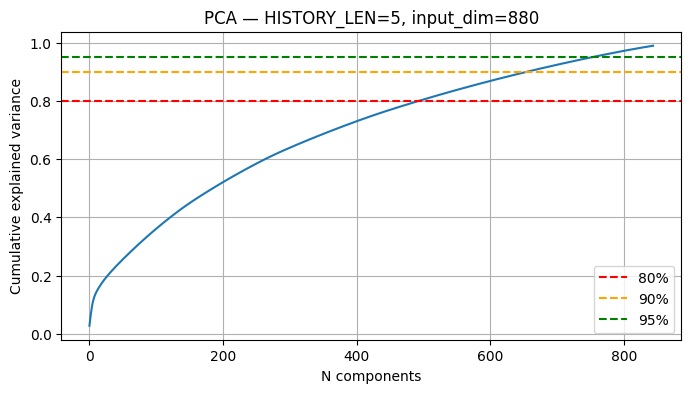

  60% variance → 264 components
  70% variance → 366 components
  80% variance → 494 components
  90% variance → 655 components
  95% variance → 752 components


In [40]:
# Load spikes for PCA diagnosis
spikes_diag, _ = load_all_nwb(TRAINING_DIR, history_len=HISTORY_LEN)
scaler_diag    = StandardScaler()
spikes_scaled  = scaler_diag.fit_transform(spikes_diag)

pca_diag = PCA(n_components=0.99).fit(spikes_scaled)  # stop at 99% — covers all thresholds you care about
cumvar   = np.cumsum(pca_diag.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(cumvar)
plt.axhline(0.80, color='r',      linestyle='--', label='80%')
plt.axhline(0.90, color='orange', linestyle='--', label='90%')
plt.axhline(0.95, color='g',      linestyle='--', label='95%')
plt.xlabel("N components")
plt.ylabel("Cumulative explained variance")
plt.title(f"PCA — HISTORY_LEN={HISTORY_LEN}, input_dim={spikes_scaled.shape[1]}")
plt.legend(); plt.grid(True); plt.show()

for threshold in [0.60, 0.70, 0.80, 0.90, 0.95]:
    n = np.argmax(cumvar >= threshold) + 1
    print(f"  {threshold:.0%} variance → {n} components")

## 6) Decoder class

In [45]:
class FMLatentDecoder(BCIDecoder):
    """
    FM-Latent: Flow Matching decoder in PCA-compressed spike space.

    Preprocessing matches h1.ipynb linear decoder exactly:
      exponential filter then StandardScaler then PCA then VelocityField
    Target: smoothed velocity (create_targets), still-times masked out.
    """

    def __init__(self, task_config: FalconConfig, batch_size: int = 1):
        super().__init__(task_config, batch_size)
        self.task_config   = task_config
        self.pca           : Optional[PCA]            = None
        self.spike_scaler  : Optional[StandardScaler] = None
        self.target_scaler : Optional[StandardScaler] = None
        self.model         : Optional[VelocityField]  = None
        self._history      : list[np.ndarray]         = []


    def fit(self, training_dir: str, task: FalconTask = FalconTask.h1):
        print("=== Loading held-in calibration data ===")
        spikes, targets = load_all_nwb(training_dir, history_len=HISTORY_LEN)
        print(f"  Spikes:  {spikes.shape}  |  Targets: {targets.shape}")

        N     = len(spikes)
        n_val = int(N * VAL_FRAC)
        n_tr  = N - n_val
        print(f"  Train: {n_tr}  |  Val: {n_val}  ({VAL_FRAC:.0%} held out)")

        spikes_tr,  spikes_val  = spikes[:n_tr],  spikes[n_tr:]
        targets_tr, targets_val = targets[:n_tr], targets[n_tr:]

        # Fit spike scaler on train only
        self.spike_scaler = StandardScaler()
        spikes_tr_sc  = self.spike_scaler.fit_transform(spikes_tr)
        spikes_val_sc = self.spike_scaler.transform(spikes_val)

        print(f"  Fitting PCA ({LATENT_DIM} components)…")
        self.pca    = PCA(n_components=LATENT_DIM)
        h_train     = self.pca.fit_transform(spikes_tr_sc).astype(np.float32)
        h_val       = self.pca.transform(spikes_val_sc).astype(np.float32)
        print(f"  Explained variance (sum): {self.pca.explained_variance_ratio_.sum():.3f}")

        # Target scaler — fit on train targets
        self.target_scaler = StandardScaler()
        y_train = self.target_scaler.fit_transform(targets_tr).astype(np.float32)
        y_val   = self.target_scaler.transform(targets_val).astype(np.float32)

        out_dim      = y_train.shape[1]
    
        self.model = VelocityField(
            out_dim    = out_dim,
            latent_dim = LATENT_DIM,   
            hidden_dim = HIDDEN_DIM,
            n_layers   = N_LAYERS,
        ).to(DEVICE)

        self._train(h_train, y_train, h_val, y_val)

   

    def _train(self, h_tr, y_tr, h_val=None, y_val=None
                ):
        epochs=EPOCHS
        lr=LR
        # pin_memory + num_workers speeds up GPU data feeding
        loader = DataLoader(
            TensorDataset(torch.tensor(h_tr), torch.tensor(y_tr)),
            batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
            pin_memory=(DEVICE == "cuda"), num_workers=0,
        )
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)

        from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
        warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
        cosine    = CosineAnnealingLR(optimizer, T_max=max(epochs - 5, 1))
        scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

        do_val = h_val is not None and y_val is not None
        if do_val:
            val_loader = DataLoader(
                TensorDataset(torch.tensor(h_val), torch.tensor(y_val)),
                batch_size=BATCH_SIZE * 4, shuffle=False,
                pin_memory=(DEVICE == "cuda"), num_workers=0,
            )
            # Keep val tensors on GPU for fast R² eval
            h_val_t = torch.tensor(h_val, device=DEVICE)
            y_val_t = torch.tensor(y_val, device=DEVICE)

        best_val_loss, best_state, no_improve = float("inf"), None, 0
        self.train_losses, self.val_losses, self.val_r2s = [], [], []

        for epoch in range(1, epochs + 1):
            self.model.train()
            total_tr = sum(
                self._step(optimizer, hb.to(DEVICE, non_blocking=True),
                                       yb.to(DEVICE, non_blocking=True))
                for hb, yb in loader
            )
            scheduler.step()
            avg_tr = total_tr / len(loader)
            self.train_losses.append(avg_tr)

            if do_val:
                self.model.eval()
                with torch.no_grad():
                    avg_val = sum(
                        fm_loss(self.model,
                                hb.to(DEVICE, non_blocking=True),
                                yb.to(DEVICE, non_blocking=True)).item()
                        for hb, yb in val_loader
                    ) / len(val_loader)
                self.val_losses.append(avg_val)

                if epoch % R2_EVAL_EVERY == 0 or epoch == 1:
                    with torch.no_grad():
                        y_hat  = euler_integrate(self.model, h_val_t).cpu().numpy()
                    y_hat_orig = self.target_scaler.inverse_transform(y_hat)
                    y_val_orig = self.target_scaler.inverse_transform(y_val)
                    r2_vw      = float(r2_score(y_val_orig, y_hat_orig,
                                                multioutput="variance_weighted"))
                    self.val_r2s.append((epoch, r2_vw))

                if avg_val < best_val_loss:
                    best_val_loss = avg_val
                    best_state    = copy.deepcopy(self.model.state_dict())
                    no_improve    = 0
                else:
                    no_improve += 1

                if epoch % 10 == 0 or epoch == 1:
                    r2_str = (f"  val_r2={self.val_r2s[-1][1]:.3f}"
                              if self.val_r2s and self.val_r2s[-1][0] == epoch else "")
                    print(f"  Epoch {epoch:4d}/{epochs}  train={avg_tr:.5f}"
                          f"  val={avg_val:.5f}  best={best_val_loss:.5f}"
                          f"  patience={no_improve}/{PATIENCE}{r2_str}")

                if no_improve >= PATIENCE:
                    print(f"  Early stopping at epoch {epoch}.")
                    break
            else:
                self.val_losses.append(None)
                if epoch % 10 == 0 or epoch == 1:
                    print(f"  Epoch {epoch:4d}/{epochs}  train={avg_tr:.5f}")

        if do_val and best_state is not None:
            self.model.load_state_dict(best_state)
            print(f"  Restored best weights (val={best_val_loss:.5f})")
        self.model.eval()

    def _step(self, optimizer, h, y):
        optimizer.zero_grad()
        loss = fm_loss(self.model, h, y)
        loss.backward()
        nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        optimizer.step()
        return loss.item()



    def evaluate(self, test_dir: str,
                 task: FalconTask = FalconTask.h1,
                 use_local_x_stats: bool = True) -> dict:
        """
        Evaluate on a held-out directory.
        use_local_x_stats=True re-centres the spike scaler to the test day,
        mirroring h1.ipynb's multiday_eval(adjust_local_xstat=True).
        """
        print(f"\n=== Evaluating on: {test_dir} ===")
        spikes, targets = load_all_nwb(test_dir, history_len=HISTORY_LEN)

        # Optionally re-fit spike scaler to test single day 
        if use_local_x_stats:
            x_mean = np.nanmean(spikes, axis=0)
            x_std  = np.nanstd(spikes, axis=0)
            x_std[x_std == 0] = 1.0
            spikes_sc = (spikes - x_mean) / x_std
        else:
            spikes_sc = self.spike_scaler.transform(spikes)

        h = self.pca.transform(spikes_sc).astype(np.float32)

        # Batch inference on GPU
        h_t   = torch.tensor(h, device=DEVICE)
        chunk  = 4096
        preds  = []
        self.model.eval()
        with torch.no_grad():
            for start in range(0, len(h_t), chunk):
                preds.append(
                    euler_integrate(self.model, h_t[start:start+chunk]).cpu().numpy()
                )
        preds = np.concatenate(preds)
        preds = self.target_scaler.inverse_transform(preds)

        r2   = r2_score(targets, preds, multioutput="raw_values")
        r2_vw = float(r2_score(targets, preds, multioutput="variance_weighted"))
        rmse = np.sqrt(np.mean((targets - preds) ** 2, axis=0))

        print(f"\n  {'Dim':<6} {'R²':>10} {'RMSE':>10}")
        print(f"  {'-'*28}")
        for i, (r, e) in enumerate(zip(r2, rmse)):
            print(f"  {i:<6} {r:>10.4f} {e:>10.4f}")
        print(f"  {'-'*28}")
        print(f"  {'Mean R² (var-weighted)':<24} {r2_vw:>10.4f}")
        print(f"  {'Mean RMSE':<24} {rmse.mean():>10.4f}")

        return {"r2_per_dim": r2, "rmse_per_dim": rmse,
                "mean_r2": r2_vw, "mean_rmse": float(rmse.mean())}



    def save(self, path: str):
        import pickle
        os.makedirs(path, exist_ok=True)
        torch.save(self.model.state_dict(), os.path.join(path, "model.pt"))
        for name, obj in [("pca", self.pca), ("spike_scaler", self.spike_scaler),
                          ("target_scaler", self.target_scaler)]:
            with open(os.path.join(path, f"{name}.pkl"), "wb") as fh:
                pickle.dump(obj, fh)
        meta = {"out_dim": self.model.out_dim, "latent_dim": LATENT_DIM,
                "hidden_dim": HIDDEN_DIM, "n_layers": N_LAYERS,
                "history_len": HISTORY_LEN, "n_channels": self.task_config.n_channels}
        with open(os.path.join(path, "meta.pkl"), "wb") as fh:
            pickle.dump(meta, fh)
        print(f"Saved to {path}")

    def load(self, path: str):
        import pickle
        with open(os.path.join(path, "meta.pkl"),          "rb") as fh: meta = pickle.load(fh)
        with open(os.path.join(path, "pca.pkl"),           "rb") as fh: self.pca = pickle.load(fh)
        with open(os.path.join(path, "spike_scaler.pkl"),  "rb") as fh: self.spike_scaler = pickle.load(fh)
        with open(os.path.join(path, "target_scaler.pkl"), "rb") as fh: self.target_scaler = pickle.load(fh)
        self.model = VelocityField(
            out_dim=meta["out_dim"], latent_dim=meta["latent_dim"],
            hidden_dim=meta["hidden_dim"], n_layers=meta["n_layers"],
        ).to(DEVICE)
        self.model.load_state_dict(
            torch.load(os.path.join(path, "model.pt"), map_location=DEVICE)
        )
        self.model.eval()
        print(f"Loaded model from {path}")
        return meta

    def reset(self, dataset_tags: List[str] = [""]):
        self._history = []
        if self.model is not None:
            self.model.eval()

    def predict(self, neural_observations: np.ndarray) -> np.ndarray:
        """
        Online decode: accumulate HISTORY_LEN exponentially-filtered bins,
        then run PCA + Euler ODE.
        neural_observations: raw spike counts for the current timestep, shape (1, n_ch).
        """
        # Exponential filter update: alpha * x_t + (1-alpha) * prev_filtered
        alpha = 1.0 - np.exp(-BIN_SIZE_MS / 20.0)
        prev  = self._history[-1] if self._history else np.zeros_like(neural_observations, dtype=np.float32)
        filtered = alpha * neural_observations.astype(np.float32) + (1.0 - alpha) * prev
        self._history.append(filtered)
        if len(self._history) > HISTORY_LEN:
            self._history.pop(0)
        while len(self._history) < HISTORY_LEN:
            self._history.insert(0, np.zeros_like(neural_observations, dtype=np.float32))

        window = np.concatenate(self._history, axis=-1)          # (1, n_ch * HISTORY_LEN)
        h      = self.pca.transform(self.spike_scaler.transform(window)).astype(np.float32)
        with torch.no_grad():
            y_pred = euler_integrate(self.model, torch.tensor(h, device=DEVICE))
        return self.target_scaler.inverse_transform(y_pred.cpu().numpy())

    def observe(self, neural_observations: np.ndarray):
        alpha = 1.0 - np.exp(-BIN_SIZE_MS / 20.0)
        prev  = self._history[-1] if self._history else np.zeros_like(neural_observations, dtype=np.float32)
        filtered = alpha * neural_observations.astype(np.float32) + (1.0 - alpha) * prev
        self._history.append(filtered)
        if len(self._history) > HISTORY_LEN:
            self._history.pop(0)

    def on_done(self, dones: np.ndarray):
        if dones.any():
            self._history = []


## 7) Train

In [49]:
task_enum = FalconTask[TASK]
cfg       = FalconConfig(task=task_enum)
decoder   = FMLatentDecoder(task_config=cfg)

decoder.fit(training_dir=TRAINING_DIR)


=== Loading held-in calibration data ===
Found 13 NWB file(s) in data/h1/held_in_calib/sub-HumanPitt-held-in-calib
  sub-HumanPitt-held-in-calib_ses-19250101T111740.nwb: kept 6191 / 10819 bins
  sub-HumanPitt-held-in-calib_ses-19250101T112404.nwb: kept 3488 / 6456 bins
  sub-HumanPitt-held-in-calib_ses-19250108T110520.nwb: kept 6863 / 12233 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111022.nwb: kept 3898 / 6786 bins
  sub-HumanPitt-held-in-calib_ses-19250108T111455.nwb: kept 3603 / 6505 bins
  sub-HumanPitt-held-in-calib_ses-19250113T120811.nwb: kept 6430 / 11646 bins
  sub-HumanPitt-held-in-calib_ses-19250113T121303.nwb: kept 6638 / 11732 bins
  sub-HumanPitt-held-in-calib_ses-19250115T110633.nwb: kept 5712 / 10071 bins
  sub-HumanPitt-held-in-calib_ses-19250115T111328.nwb: kept 7035 / 12267 bins
  sub-HumanPitt-held-in-calib_ses-19250119T113543.nwb: kept 6788 / 11951 bins
  sub-HumanPitt-held-in-calib_ses-19250119T114045.nwb: kept 6715 / 12022 bins
  sub-HumanPitt-held-in-calib_

## 8) Plot Training Metrics

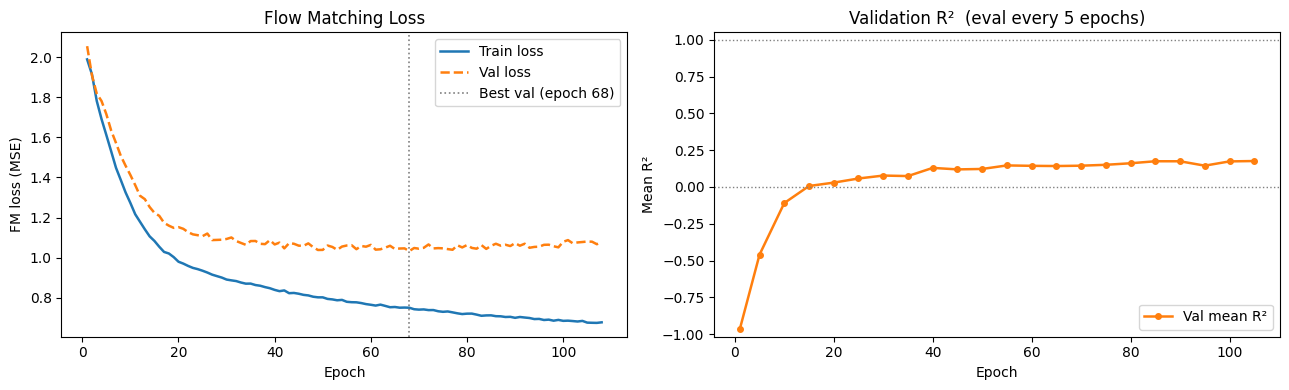

In [50]:
epochs_axis = range(1, len(decoder.train_losses) + 1)
has_val = any(v is not None for v in decoder.val_losses)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


ax = axes[0]
ax.plot(epochs_axis, decoder.train_losses, label="Train loss", linewidth=1.8)
if has_val:
    ax.plot(epochs_axis, decoder.val_losses, label="Val loss",
            linewidth=1.8, linestyle="--")
    best_epoch = int(np.argmin(decoder.val_losses)) + 1
    ax.axvline(best_epoch, color="grey", linestyle=":", linewidth=1.2,
               label=f"Best val (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("FM loss (MSE)")
ax.set_title("Flow Matching Loss")
ax.legend()


ax = axes[1]
if decoder.val_r2s:
    r2_epochs, r2_vals = zip(*decoder.val_r2s)
    ax.plot(r2_epochs, r2_vals, color="tab:orange", marker="o",
            markersize=4, linewidth=1.8, label="Val mean R²")
    ax.axhline(0, color="grey", linestyle=":", linewidth=1)
    ax.axhline(1, color="grey", linestyle=":", linewidth=1)
    ax.set_ylim(min(0, min(r2_vals)) - 0.05, 1.05)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean R²")
    ax.set_title(f"Validation R²  (eval every {R2_EVAL_EVERY} epochs)")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No validation R² recorded\n(set do_val=True)",
            ha="center", va="center", transform=ax.transAxes, color="grey")

fig.tight_layout()
plt.show()

## 9) Save checkpoint

In [51]:
decoder.save(SAVE_DIR)


Saved to /content/drive/MyDrive/


## 10) Evaluate on held-out calibration data

In [52]:
# Evaluate with local x-stat adaptation (mirrors h1.ipynb multiday adjust)
metrics_held_out = decoder.evaluate(test_dir=TEST_DIR,  use_local_x_stats=True)
metrics_minival  = decoder.evaluate(test_dir=MINIVAL_DIR, use_local_x_stats=True)

print(f"\nSummary")
print(f"  Held-out  Mean R² (var-weighted): {metrics_held_out['mean_r2']:.4f}")
print(f"  Held-out  Mean RMSE             : {metrics_held_out['mean_rmse']:.4f}")
print(f"  Minival   Mean R² (var-weighted): {metrics_minival['mean_r2']:.4f}  (FALCON sklearn baseline: 0.195)")
print(f"  Minival   Mean RMSE             : {metrics_minival['mean_rmse']:.4f}")



=== Evaluating on: data/h1/held_out_calib/sub-HumanPitt-held-out-calib ===
Found 14 NWB file(s) in data/h1/held_out_calib/sub-HumanPitt-held-out-calib
  sub-HumanPitt-held-out-calib_ses-19250126T113454.nwb: kept 1268 / 2376 bins
  sub-HumanPitt-held-out-calib_ses-19250126T114029.nwb: kept 1325 / 2408 bins
  sub-HumanPitt-held-out-calib_ses-19250127T120333.nwb: kept 1361 / 2454 bins
  sub-HumanPitt-held-out-calib_ses-19250127T120826.nwb: kept 1475 / 2647 bins
  sub-HumanPitt-held-out-calib_ses-19250129T112555.nwb: kept 1385 / 2469 bins
  sub-HumanPitt-held-out-calib_ses-19250129T113059.nwb: kept 1294 / 2347 bins
  sub-HumanPitt-held-out-calib_ses-19250202T113958.nwb: kept 1342 / 2406 bins
  sub-HumanPitt-held-out-calib_ses-19250202T114452.nwb: kept 1426 / 2496 bins
  sub-HumanPitt-held-out-calib_ses-19250203T113515.nwb: kept 1271 / 2369 bins
  sub-HumanPitt-held-out-calib_ses-19250203T114018.nwb: kept 1325 / 2303 bins
  sub-HumanPitt-held-out-calib_ses-19250206T112219.nwb: kept 1381 / 

## 11) Load a saved checkpoint and re-evaluate 

In [ ]:
# Useful if the Colab session restarted and you want to skip retraining.
# Uncomment and run:

# decoder2 = FMLatentDecoder(task_config=cfg)
# decoder2.load(SAVE_DIR)
# metrics2 = decoder2.evaluate(test_dir=TEST_DIR, task=task_enum)